In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
from google.colab import userdata
KAGGLE_KEY = userdata.get('kaggle_key')
kagglehub.login(KAGGLE_KEY)


Kaggle credentials set.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

page0526_chromosome_dataset_path = kagglehub.dataset_download('page0526/chromosome-dataset')

print('Data source import complete.')


100%|██████████| 54.4M/54.4M [00:00<00:00, 66.1MB/s]

Extracting files...


Data source import complete.


In [4]:
import shutil

shutil.move(page0526_chromosome_dataset_path, '/content/data')

'/content/data'

In [5]:
import numpy as np
import pandas as pd
import os

from torch.utils.data import DataLoader, Dataset
import torch.utils.data as utils
from torchvision import transforms
from timm import create_model

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image

In [6]:
def load_images(main_folder):
    image_data = []

    for chrom in range(0, 25):
        chrom_folder = os.path.join(main_folder, str(chrom))

        if not os.path.isdir(chrom_folder):
            continue

        # Get all TIFF files in the subfolder
        tiff_files = [f for f in os.listdir(chrom_folder) if f.lower().endswith(('.tiff', '.tif'))]

        for file in tiff_files:
            file_path = os.path.join(chrom_folder, file)
            image = Image.open(file_path)
            image_data.append((image, chrom))

    return image_data

In [7]:
import shutil

# move data to /content 4 easy access
# shutil.move(page0526_chromosome_dataset_path, '/content/data')

In [12]:
dataset_path = '/content/data/train_data/final/single_chromosome'

In [13]:
ims = load_images(dataset_path)

print(f"Loaded {len(ims)} TIFF images")

if ims:
    ims[0][0].show()
    print(f"Label of first image: {ims[0][1]}")

Loaded 25299 TIFF images
Label of first image: 1


In [14]:
from PIL.TiffImagePlugin import TiffImageFile
import random

def visualize(ims_list, num=25):
  display = min(len(ims_list), num)
  cols = int(np.ceil(np.sqrt(display)))
  rows = int((np.ceil(display / cols)))

  plt.figure(figsize=(cols * 2, rows * 2))

  if len(ims_list) > 0:
    indices = random.sample(range(len(ims_list)), display)

  for i, idx in enumerate(indices):
    plt.subplot(rows, cols, i + 1)
    im, label = ims_list[idx]

    # if tensor, convert to numpy
    if hasattr(im, 'detach'):
      im = im.detach().cpu().numpy()
    if isinstance(im, TiffImageFile):
      im = np.array(im)

    # (C, H, W) to (H, W, C)
    if im.shape == 3 and im.shape[0] in [1, 3]:
      im=np.transpose(im, (1, 2, 0))

    # normalize
    if im.max() > 1.0:
      im = im/255.0

    plt.imshow(im, cmap='gray')
    plt.title(str(label))
    plt.axis('off')

  plt.tight_layout()
  plt.show()


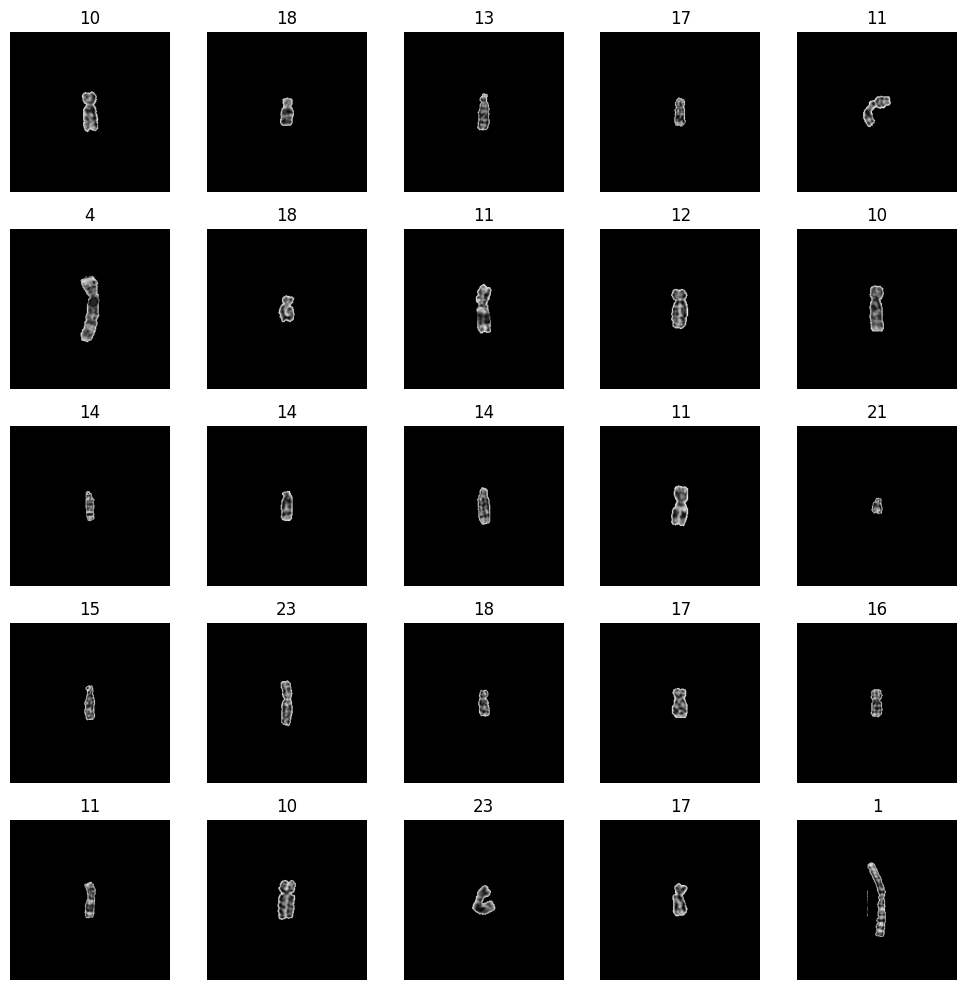

In [15]:
visualize(ims)

In [16]:
class ChromosomeDataset(Dataset):
    def __init__(self, folder, ims_list=None, transform=None):
        self.image_data = load_images(folder) if ims_list is None else ims_list
        self.transform = transform if transform is not None else transforms.ToTensor()

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        im, label = self.image_data[idx]

        if self.transform:
            im = self.transform(im)
        return im, label - 1

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
EPOCHS = 25
WORKERS = 2
train_path = '/content/data/train_data/final/single_chromosome'
test_path = '/content/data/test_data/single_chromosome'

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # EfficientNet normalization
])

trainset = ChromosomeDataset(train_path, ims, transform=transform)
testset = ChromosomeDataset(test_path, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS)

In [19]:
all_train_labels = [label for _, label in trainset]
unique_train_classes = sorted(set(all_train_labels))

print("Unique classes in training set:", unique_train_classes)

Unique classes in training set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [20]:
im, labels = next(iter(trainloader))
print(f"Batch image shape: {im.shape}, Batch labels: {labels}")
len(trainset), len(testset)

Batch image shape: torch.Size([32, 3, 224, 224]), Batch labels: tensor([16, 18,  1, 11, 20, 20, 11,  9, 13, 16, 10, 19, 13, 10,  5,  0,  9,  4,
         9, 22,  8, 12,  5,  3,  8, 15, 21, 22, 13,  7,  1,  0])


(25299, 2801)

In [1]:
model = create_model('efficientnet_b1', pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Linear(model.classifier.in_features, 24)
model = model.to(device)

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters())

train_losses = []
val_losses = []

# Training Loop with tqdm for progress bar
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    with tqdm(trainloader, total=len(trainloader), desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()  # Zero gradients
            output = model(data)

            loss = loss_func(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Update progress bar description with loss value
            pbar.set_postfix(loss=loss.item())

    # Store training loss for plotting
    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    # Validation after every epoch
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0


    with torch.no_grad(), tqdm(testloader, total=len(testloader), desc="Validation", unit="batch") as pbar:
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += loss_func(output, target).item()
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            pbar.set_postfix(val_loss=val_loss / (batch_idx + 1))

    avg_val_loss = val_loss / len(testloader)
    val_losses.append(avg_val_loss)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}], Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%")

print('Training complete!')

NameError: name 'create_model' is not defined

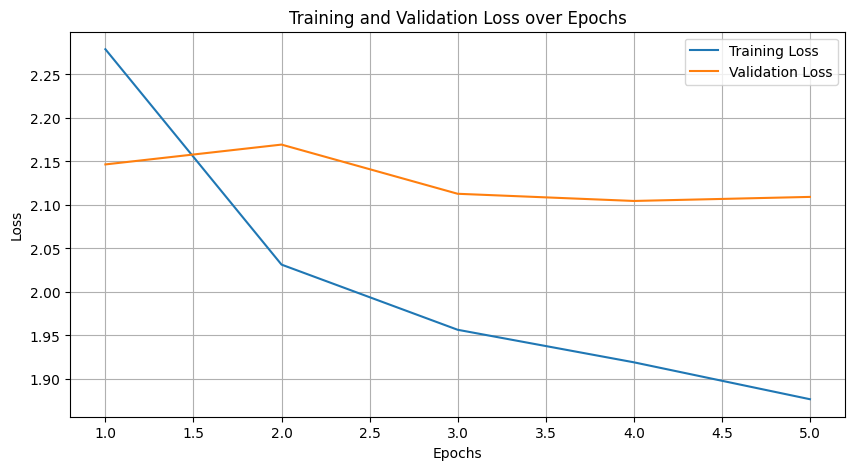

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()